## Victor Flávio Arantes

In [6]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

2025-01-16 15:36:14.169849: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-16 15:36:14.179974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737056174.191862   12290 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737056174.195266   12290 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-16 15:36:14.207327: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [26]:
path= '/home/turma02/lgacademy/folhasamostras/classe1/'

In [27]:
num_classes = 2

In [28]:
modelo_base = ResNet50(weights='imagenet', include_top = False, input_shape = (224, 224, 3))

In [29]:
modelo_novo = modelo_base.output
modelo_novo = GlobalAveragePooling2D()(modelo_novo)
modelo_novo = Dense(1024, activation = 'relu')(modelo_novo)
predicoes = Dense(num_classes, activation = 'softmax')(modelo_novo)

In [30]:
modelo = Model(inputs = modelo_base.input, outputs = predicoes)

In [31]:
for layer in modelo_base.layers:
    layer.trainable = False

In [32]:
modelo.compile(optimizer=Adam(learning_rate=0.001),
               loss = 'categorical_crossentropy',
               metrics=['accuracy'])

In [33]:
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

In [34]:
validation_datagen = ImageDataGenerator(preprocessing_function = preprocess_input)

In [36]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(path, 'Train'),
    target_size = (224, 224),
    batch_size = 10,
    class_mode = 'categorical'
)

Found 48 images belonging to 2 classes.


In [37]:
validation_generator = validation_datagen.flow_from_directory(
    os.path.join(path, 'Test'),
    target_size = (224, 224),
    batch_size = 10,
    class_mode = 'categorical'
)

Found 12 images belonging to 2 classes.


In [38]:
modelo.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,687,938 (97.99 MB)

 Trainable params: 2,100,226 (8.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [39]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import load_img

In [60]:
class_labels = list(validation_generator.class_indices.keys())
def classifica_imagem(imagem):
    img = load_img(imagem, target_size = (224, 224))
    img_ = image.img_to_array(img)
    img_ = np.expand_dims(img_, axis = 0)
    img_ = preprocess_input(img_)
    preds = modelo.predict(img_)
    classe_predita = np.argmax(preds, axis = 1)[0]
    rotulo_predito = class_labels[classe_predita]
    print(f"Classe predita: {rotulo_predito} - {preds[0][classe_predita]:.4}")
    

In [61]:
history = modelo.fit(
    train_generator,
    steps_per_epoch = train_generator.samples // train_generator.batch_size,
    validation_data = validation_generator,
    validation_steps = validation_generator.samples // validation_generator.batch_size,
    epochs = 20
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step - accuracy: 1.0000 - loss: 9.9451e-04 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 2.6652e-04 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 0.0056
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - loss: 9.7151e-04 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 0.0073
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - v

In [62]:
modelo.save('resnet_10_epoch_folhasamostras.keras')

In [76]:
imagem = path + 'amostra5.jpeg'

In [77]:
path

'/home/turma02/lgacademy/folhasamostras/classe1/'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Classe predita: Defeituosa - 1.0000


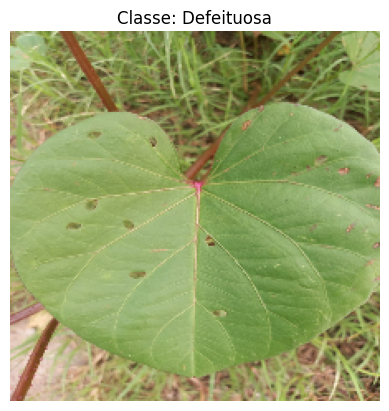

In [78]:
class_labels = list(validation_generator.class_indices.keys())

def classifica_imagem(imagem):
    
    img = load_img(imagem, target_size=(224, 224))
    img_ = image.img_to_array(img)
    img_ = np.expand_dims(img_, axis=0)
    img_ = preprocess_input(img_)

    preds = modelo.predict(img_)
    classe_predita = np.argmax(preds, axis=1)[0]
    rotulo_predito = class_labels[classe_predita]

    print(f"Classe predita: {rotulo_predito} - {preds[0][classe_predita]:.4f}")

    plt.imshow(img)
    plt.title(f"Classe: {rotulo_predito}")
    plt.axis("off")
    plt.show()

classifica_imagem(imagem)